# Big Belly Forecasting - Modeling Notebook

---

## About This Notebook

Trains and evaluates all forecasting models. Produces per-bin P10/P50/P90
uncertainty outputs that feed into the operational forecast notebook.

**Models evaluated:**
1. Naive baseline — per-bin day-of-week historical average (minimum benchmark)
2. Prophet — aggregate daily collections with seasonality and exogenous regressors
3. XGBoost binary classification — "does this bin need collection?" (re-run with full data + tuning)
4. LightGBM quantile regression — per-bin time-to-full with P10/P50/P90 uncertainty bounds

**Exogenous features added over Preliminary Analysis:**
- Weather: daily max temp, min temp, precipitation, wind (Open-Meteo, Berkeley station)
- Campus events: semester flags, spring recess, RRR week, finals week, Cal Day, 4/20,
  commencement, move-in week, football home games (2023–2025) — from official UC Berkeley
  academic calendars (2023-24, 2024-25, 2025-26)

**Train/test split:** 2023–2024 train, 2025–present test (per Problem Statement)

**Required files (same directory as notebook):**
| File | Description |
|---|---|
| `Daily Collection Activity - CLEAN 2024 (1).csv` | CLEAN export — 2023 data |
| `Daily Collection Activity - CLEAN 2025 (1).csv` | CLEAN export — 2024 data |
| `Daily Collection Activity - CLEAN 2026 (1).csv` | CLEAN export — 2025–2026 data |
| `bin_fill_curve_coefficients.csv` | Per-bin fill-curve coefficients (Phase 1) |


## 0. Install Dependencies

Run this cell first. Installs weather fetch libraries if not already present.
Safe to re-run — will not reinstall if already installed.

In [1]:
import importlib, subprocess

# Packages to install via pip if not already present
pip_packages = [
    'openmeteo-requests',
    'requests-cache',
    'retry-requests',
    'lightgbm',
    'xgboost',
    'prophet',
]

# importlib name differs from pip name for some packages
import_names = {
    'openmeteo-requests': 'openmeteo_requests',
    'requests-cache':     'requests_cache',
    'retry-requests':     'retry_requests',
    'lightgbm':           'lightgbm',
    'xgboost':            'xgboost',
    'prophet':            'prophet',
}

for pip_name in pip_packages:
    import_name = import_names[pip_name]
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.run(['pip', 'install', pip_name, '--break-system-packages', '-q'])
        print(f"  {pip_name} installed.")
    else:
        print(f"  {import_name} already installed.")

print('Complete')

Installing openmeteo-requests...
  openmeteo-requests installed.
Installing requests-cache...
  requests-cache installed.
Installing retry-requests...
  retry-requests installed.
Installing lightgbm...
  lightgbm installed.
Installing xgboost...
  xgboost installed.
  prophet already installed.
Complete


## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import warnings
import json
from datetime import datetime, timedelta

import lightgbm as lgb
import xgboost as xgb
from prophet import Prophet
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             roc_auc_score, classification_report)
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ── File paths ────────────────────────────────────────────────────────────────
files = [
    'Daily Collection Activity - CLEAN 2024 (1).csv',
    'Daily Collection Activity - CLEAN 2025 (1).csv',
    'Daily Collection Activity - CLEAN 2026 (1).csv',
]
COEFFS_PATH = 'bin_fill_curve_coefficients.csv'

# ── Constants ─────────────────────────────────────────────────────────────────
THRESHOLD   = 60.0
TRAIN_END   = '2024-12-31'
TEST_START  = '2025-01-01'
STREAM_MAP  = {
    'Waste':        'Landfill',
    'Compostables': 'Compostables',
    'Bottles/Cans': 'Recyclables',
}
STREAM_COLORS = {
    'Landfill':     '#e74c3c',
    'Compostables': '#27ae60',
    'Recyclables':  '#2980b9',
}


## 2. Load and Clean CLEAN Export Data

In [3]:
def load_clean_csv(path):
    df = pd.read_csv(path, skiprows=10)
    df.columns = df.columns.str.strip()
    return df

raw_frames = []
for f in files:
    try:
        raw_frames.append(load_clean_csv(f))
        print(f"Loaded: {f}  ({len(raw_frames[-1]):,} rows)")
    except FileNotFoundError:
        print(f"NOT FOUND: {f}")

log = pd.concat(raw_frames, ignore_index=True)
log = log.rename(columns={
    'Serial':                       'serial',
    'Description':                  'location',
    'Stream Type':                  'stream_type_raw',
    'Reason':                       'collection_reason',
    'Fullness Level at Collection': 'fullness_raw',
    'Collection Time':              'timestamp',
})
log['timestamp'] = pd.to_datetime(log['timestamp'], errors='coerce')
log['fullness_pct'] = (
    log['fullness_raw'].astype(str).str.strip()
    .str.replace('%', '', regex=False)
    .str.replace(r'\xa0.*', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)
log['stream_type'] = log['stream_type_raw'].map(STREAM_MAP).fillna(log['stream_type_raw'])
log = log.dropna(subset=['serial', 'timestamp', 'fullness_pct'])
log = log[log['stream_type'].isin(['Landfill', 'Compostables', 'Recyclables'])]
log['serial'] = log['serial'].astype(int)
log = log[log['timestamp'].dt.year >= 2023]
log = log.sort_values(['serial', 'timestamp']).reset_index(drop=True)
log['date'] = log['timestamp'].dt.normalize()

print(f"\nCombined: {len(log):,} events | {log['serial'].nunique()} bins")
print(f"Date range: {log['timestamp'].min().date()} to {log['timestamp'].max().date()}")


Loaded: Daily Collection Activity - CLEAN 2024 (1).csv  (14,568 rows)
Loaded: Daily Collection Activity - CLEAN 2025 (1).csv  (18,097 rows)
Loaded: Daily Collection Activity - CLEAN 2026 (1).csv  (27,279 rows)

Combined: 59,111 events | 248 bins
Date range: 2023-01-03 to 2026-02-20


## 3. Weather Data (Open-Meteo)

Fetches daily weather for UC Berkeley (37.87°N, 122.27°W) from the Open-Meteo
historical archive API. No API key required.

If the fetch fails, the notebook falls back to weather-free features and flags it.


In [4]:
weather = None

try:
    import openmeteo_requests
    import requests_cache
    from retry_requests import retry

    cache_session = requests_cache.CachedSession('.weather_cache', expire_after=-1)
    retry_session = retry(cache_session, retries=3, backoff_factor=0.2)
    om = openmeteo_requests.Client(session=retry_session)

    params = {
        'latitude':         37.8716,
        'longitude':        -122.2727,
        'start_date':       '2023-01-01',
        'end_date':         datetime.now().strftime('%Y-%m-%d'),
        'daily':            ['temperature_2m_max', 'temperature_2m_min',
                             'precipitation_sum', 'wind_speed_10m_max'],
        'timezone':         'America/Los_Angeles',
        'temperature_unit': 'fahrenheit',
    }
    r = om.weather_api('https://archive-api.open-meteo.com/v1/archive', params=params)[0]
    daily = r.Daily()
    n = daily.Variables(0).ValuesAsNumpy().shape[0]
    weather = pd.DataFrame({
        'date':      pd.date_range(start='2023-01-01', periods=n, freq='D'),
        'temp_max':  daily.Variables(0).ValuesAsNumpy(),
        'temp_min':  daily.Variables(1).ValuesAsNumpy(),
        'precip_mm': daily.Variables(2).ValuesAsNumpy(),
        'wind_max':  daily.Variables(3).ValuesAsNumpy(),
    })
    # Derived features
    weather['temp_avg']    = (weather['temp_max'] + weather['temp_min']) / 2
    weather['is_rainy']    = (weather['precip_mm'] > 2.5).astype(int)
    weather['is_hot']      = (weather['temp_max'] > 80).astype(int)
    weather['is_cold']     = (weather['temp_max'] < 55).astype(int)
    print(f"Weather loaded: {len(weather)} days")
    print(weather.tail(3).to_string(index=False))

except Exception as e:
    print(f"Weather fetch failed ({e}). Continuing without weather features.")
    print("Weather features will be set to 0 — rerun with internet access for best results.")


Weather loaded: 1187 days
      date  temp_max  temp_min  precip_mm  wind_max  temp_avg  is_rainy  is_hot  is_cold
2026-03-30 75.110001 53.869999   0.000000 14.128566 64.489998         0       0        0
2026-03-31 65.930000 54.500000  12.900002 26.652765 60.215000         1       0        0
2026-04-01 60.439999 54.049999   5.399999 24.152889 57.244999         1       0        0


## 4. Campus Events Feature Table

Hardcoded from official UC Berkeley academic calendars (2023–24, 2024–25, 2025–26)
and Cal Bears football schedules. Covers the full training and test period.

| Feature | Description |
|---|---|
| `is_semester` | Instruction in session (classes actively running) |
| `is_spring_recess` | Spring recess week — campus largely depopulated |
| `is_rrr_week` | Reading/Review/Recitation week — no formal classes, students still present |
| `is_finals_week` | Final exam week — high library/campus use, minimal social gatherings |
| `is_high_impact_event` | Cal Day, 4/20, commencement, football home games |
| `is_movein_week` | Fall move-in / orientation — elevated activity before instruction begins |

**Update cadence:**
- Football schedule: released ~Apr each year → update `HIGH_IMPACT` list
- Cal Day: announced ~Feb each year → update `HIGH_IMPACT` list  
- Fall semester dates: published by Registrar ~Aug → update `SEMESTERS`, `MOVEIN`
- Calendar source: https://registrar.berkeley.edu/calendar/


In [5]:
event_rows = []

# ── Semester instruction periods ──────────────────────────────────────────────
# Source: UC Berkeley Office of the Registrar (official academic calendars).
# Dates = first day of instruction through last day of instruction (incl. RRR week).
# The calendar shifts slightly each year; update each August when registrar publishes.
# Pattern: Fall instruction ~last Wed of Aug → ~2nd Fri of Dec
#          Spring instruction ~3rd Tue of Jan → ~2nd Fri of May
SEMESTERS = [
    ('2023-08-23', '2023-12-08'),   # Fall 2023
    ('2024-01-16', '2024-05-03'),   # Spring 2024
    ('2024-08-28', '2024-12-13'),   # Fall 2024
    ('2025-01-21', '2025-05-09'),   # Spring 2025
    ('2025-08-27', '2025-12-12'),   # Fall 2025
    ('2026-01-20', '2026-05-08'),   # Spring 2026 (confirmed: registrar 2025-26 calendar)
    # TO UPDATE: add Fall 2026 when registrar publishes (~Aug 2026)
    # Estimated Fall 2026: ('2026-08-26', '2026-12-11')
]
for start, end in SEMESTERS:
    for d in pd.date_range(start, end):
        event_rows.append({'date': d, 'is_semester': 1})

# ── Spring recess (low campus activity) ───────────────────────────────────────
# Full recess block including Academic & Administrative Holiday on the Friday.
# Pattern: week of ~3rd Mon of March (Mon–Fri).
RECESSES = [
    ('2024-03-25', '2024-03-29'),   # Spring 2024 recess
    ('2025-03-24', '2025-03-28'),   # Spring 2025 recess
    ('2026-03-23', '2026-03-27'),   # Spring 2026: Mon 3/23–Thu 3/26 recess + Fri 3/27 holiday
]
for start, end in RECESSES:
    for d in pd.date_range(start, end):
        event_rows.append({'date': d, 'is_spring_recess': 1})

# ── Reading / Review / Recitation (RRR) week ──────────────────────────────────
# Formal classes end; campus present but lighter foot traffic than instruction weeks.
# Pattern: Mon–Fri immediately after formal classes end, before finals.
RRR_WEEKS = [
    ('2023-12-04', '2023-12-08'),   # Fall 2023 RRR
    ('2024-05-06', '2024-05-10'),   # Spring 2024 RRR
    ('2024-12-09', '2024-12-13'),   # Fall 2024 RRR
    ('2025-05-05', '2025-05-09'),   # Spring 2025 RRR
    ('2025-12-08', '2025-12-12'),   # Fall 2025 RRR (confirmed: registrar 2025-26 calendar)
    ('2026-05-04', '2026-05-08'),   # Spring 2026 RRR (confirmed: registrar 2025-26 calendar)
]
for start, end in RRR_WEEKS:
    for d in pd.date_range(start, end):
        event_rows.append({'date': d, 'is_rrr_week': 1})

# ── Finals week (campus present but different activity pattern) ────────────────
# Pattern: Mon–Fri immediately after RRR week.
FINALS_WEEKS = [
    ('2023-12-11', '2023-12-15'),   # Fall 2023 finals
    ('2024-05-13', '2024-05-17'),   # Spring 2024 finals
    ('2024-12-16', '2024-12-20'),   # Fall 2024 finals
    ('2025-05-12', '2025-05-16'),   # Spring 2025 finals
    ('2025-12-15', '2025-12-19'),   # Fall 2025 finals (confirmed: registrar 2025-26 calendar)
    ('2026-05-11', '2026-05-15'),   # Spring 2026 finals (confirmed: registrar 2025-26 calendar)
]
for start, end in FINALS_WEEKS:
    for d in pd.date_range(start, end):
        event_rows.append({'date': d, 'is_finals_week': 1})

# ── High-impact events ────────────────────────────────────────────────────────
# Cal Day: large open-house prospective-student event (~30k visitors), typically 3rd Sat of Apr
# 4/20: annual large outdoor gathering at Memorial Glade
# Spring Commencement: typically Sat after finals end
# Winter Commencement: Sat after fall finals end
# Football home games: California Memorial Stadium (~63k capacity)
HIGH_IMPACT = [
    # ── Cal Day (prospective student open house) ──
    '2023-04-15',                   # Cal Day 2023
    '2024-04-13',                   # Cal Day 2024
    '2025-04-19',                   # Cal Day 2025
    # 2026 Cal Day TBD (calday.berkeley.edu) — estimated 2026-04-18 (3rd Sat of Apr)

    # ── 4/20 gathering (Memorial Glade) ──
    '2023-04-20',
    '2024-04-20',
    '2025-04-20',
    '2026-04-20',                   # Recurring fixed date

    # ── Spring Commencement ──
    '2023-05-13',
    '2024-05-11',
    '2025-05-17',
    '2026-05-16',                   # Confirmed: registrar 2025-26 calendar

    # ── Winter Commencement ──
    '2023-12-16',
    '2024-12-21',
    '2025-12-20',                   # Confirmed: registrar 2025-26 calendar
    # 2026 Winter Commencement: estimated 2026-12-19 (Sat after fall finals)

    # ── Football home games 2023 (California Memorial Stadium) ──
    '2023-09-09', '2023-09-16', '2023-09-30', '2023-10-07',
    '2023-10-28', '2023-11-04', '2023-11-18',

    # ── Football home games 2024 ──
    '2024-08-31', '2024-09-14', '2024-10-05', '2024-10-19',
    '2024-10-26', '2024-11-16', '2024-11-23',

    # ── Football home games 2025 ──
    '2025-09-06', '2025-09-13', '2025-10-04', '2025-10-17',
    '2025-11-01', '2025-11-15', '2025-11-29',

    # ── Football home games 2026: UPDATE when schedule is released (typically Mar/Apr) ──
    # See https://calbears.com/sports/football/schedule
]
for d in HIGH_IMPACT:
    event_rows.append({'date': pd.Timestamp(d), 'is_high_impact_event': 1})

# ── Move-in / orientation week ────────────────────────────────────────────────
# Semester begins ~Wed; move-in/orientation runs the full preceding week.
# Pattern: week before instruction begins (Mon–Wed of semester start).
MOVEIN = [
    ('2023-08-16', '2023-08-23'),   # Fall 2023 move-in
    ('2024-08-21', '2024-08-28'),   # Fall 2024 move-in
    ('2025-08-20', '2025-08-27'),   # Fall 2025 move-in (confirmed: semester begins 2025-08-20)
    # Fall 2026 move-in: estimated ('2026-08-19', '2026-08-26') — confirm when registrar publishes
]
for start, end in MOVEIN:
    for d in pd.date_range(start, end):
        event_rows.append({'date': d, 'is_movein_week': 1})

# ── Build events dataframe ─────────────────────────────────────────────────────
events_df = (
    pd.DataFrame(event_rows)
    .groupby('date').max().fillna(0).astype(int).reset_index()
)
# Ensure all feature columns exist even if no rows were added for a category
for col in ['is_semester', 'is_spring_recess', 'is_rrr_week', 'is_finals_week',
            'is_high_impact_event', 'is_movein_week']:
    if col not in events_df.columns:
        events_df[col] = 0
events_df['date'] = pd.to_datetime(events_df['date'])

print(f"Event table: {len(events_df)} dates")
print("Semester days:          ", events_df['is_semester'].sum())
print("Spring recess days:     ", events_df['is_spring_recess'].sum())
print("RRR week days:          ", events_df['is_rrr_week'].sum())
print("Finals week days:       ", events_df['is_finals_week'].sum())
print("High-impact event days: ", events_df['is_high_impact_event'].sum())
print("Move-in days:           ", events_df['is_movein_week'].sum())


Event table: 716 dates
Semester days:           651
Spring recess days:      15
RRR week days:           30
Finals week days:        30
High-impact event days:  35
Move-in days:            24


## 5. Feature Engineering

Builds the modeling dataset. Each row = one collection event.
Target variable: `hours_to_next` — hours until the next collection event for that bin.
Rows where the next collection reason is "Not Ready" are flagged but retained
(the model learns that some intervals end in wasted trips).


In [6]:
coeffs = pd.read_csv(COEFFS_PATH)
coeffs['stream_type'] = coeffs['stream_type'].map(STREAM_MAP).fillna(coeffs['stream_type'])

def build_features(log, events_df, weather, coeffs):
    df = log.copy()

    # ── Time features ─────────────────────────────────────────────────────────
    df['dow']        = df['timestamp'].dt.dayofweek
    df['month']      = df['timestamp'].dt.month
    df['week']       = df['timestamp'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['dow_sin']    = np.sin(2 * np.pi * df['dow'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['dow'] / 7)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)

    # ── Per-bin history ───────────────────────────────────────────────────────
    df = df.sort_values(['serial', 'timestamp'])
    df['elapsed_hours']  = (
        df.groupby('serial')['timestamp'].diff().dt.total_seconds() / 3600
    )
    df['prev_fullness']  = df.groupby('serial')['fullness_pct'].shift(1)
    df['roll7_elapsed']  = df.groupby('serial')['elapsed_hours'].transform(
        lambda x: x.rolling(7, min_periods=2).mean()
    )
    df['roll28_elapsed'] = df.groupby('serial')['elapsed_hours'].transform(
        lambda x: x.rolling(28, min_periods=4).mean()
    )
    df['roll7_fullness'] = df.groupby('serial')['fullness_pct'].transform(
        lambda x: x.rolling(7, min_periods=2).mean()
    )

    # ── Target ────────────────────────────────────────────────────────────────
    df['hours_to_next']    = (
        df.groupby('serial')['timestamp'].shift(-1) - df['timestamp']
    ).dt.total_seconds() / 3600
    df['next_reason']      = df.groupby('serial')['collection_reason'].shift(-1)
    df['next_is_needed']   = df['next_reason'].isin(['Fullness', 'Age']).astype(int)
    df['binary_target']    = (df['fullness_pct'] >= THRESHOLD).astype(int)


    # ── Campus events ─────────────────────────────────────────────────────────
    df = df.merge(events_df, on='date', how='left')
    for col in ['is_semester', 'is_spring_recess', 'is_rrr_week', 'is_finals_week',
                  'is_high_impact_event', 'is_movein_week']:
        df[col] = df[col].fillna(0).astype(int)

    # ── Weather ───────────────────────────────────────────────────────────────
    if weather is not None:
        df = df.merge(weather, on='date', how='left')
        for col in ['temp_max', 'temp_min', 'temp_avg', 'precip_mm',
                    'wind_max', 'is_rainy', 'is_hot', 'is_cold']:
            df[col] = df[col].fillna(df[col].median())
    else:
        for col in ['temp_max', 'temp_min', 'temp_avg', 'precip_mm',
                    'wind_max', 'is_rainy', 'is_hot', 'is_cold']:
            df[col] = 0

    # ── Bin identity from coefficients ────────────────────────────────────────
    bin_stats = coeffs[[
        'serial', 'median_elapsed_hours', 'mean_fullness_at_collection',
        'pct_wasted_trips', 'fill_pct_at_24h', 'fill_pct_at_48h', 'fill_pct_at_72h'
    ]]
    df = df.merge(bin_stats, on='serial', how='left')
    df['location_id'] = df['location'].astype('category').cat.codes

    # ── Stream dummies ────────────────────────────────────────────────────────
    stream_dummies = pd.get_dummies(df['stream_type'], prefix='stream')
    df = pd.concat([df, stream_dummies], axis=1)

    return df

df = build_features(log, events_df, weather, coeffs)

# Drop rows missing essential features or target
df_model = df.dropna(subset=[
    'hours_to_next', 'elapsed_hours', 'prev_fullness',
    'fill_pct_at_24h', 'fill_pct_at_72h'
]).copy()
df_model = df_model[df_model['next_is_needed'] == True].copy()
df_model = df_model[df_model['hours_to_next'].between(1, 21 * 24)]

print(f"Modeling dataset: {len(df_model):,} events")
print(f"Train: {(df_model['timestamp'] <= TRAIN_END).sum():,} | Test: {(df_model['timestamp'] >= TEST_START).sum():,}")


Modeling dataset: 35,410 events
Train: 21,840 | Test: 13,570


## 6. Train / Test Split

In [7]:
train = df_model[df_model['timestamp'] <= TRAIN_END].copy()
test  = df_model[df_model['timestamp'] >= TEST_START].copy()

FEATURE_COLS = [
    # Temporal
    'dow', 'month', 'week', 'is_weekend',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Bin state
    'elapsed_hours', 'prev_fullness',
    'roll7_elapsed', 'roll28_elapsed', 'roll7_fullness',
    # Campus events
    'is_semester', 'is_spring_recess', 'is_rrr_week', 'is_finals_week',
    'is_high_impact_event', 'is_movein_week',
    # Weather
    'temp_max', 'temp_min', 'precip_mm', 'wind_max',
    'is_rainy', 'is_hot', 'is_cold',
    # Bin identity
    'location_id',
    'median_elapsed_hours', 'mean_fullness_at_collection',
    'pct_wasted_trips', 'fill_pct_at_24h', 'fill_pct_at_48h', 'fill_pct_at_72h',
] + [c for c in df_model.columns if c.startswith('stream_') and df_model[c].dtype != object]

# Ensure no object columns slip through
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_model.columns and df_model[c].dtype != object]

X_train, y_train = train[FEATURE_COLS], train['hours_to_next']
X_test,  y_test  = test[FEATURE_COLS],  test['hours_to_next']

print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {len(FEATURE_COLS)}")


Train: 21,840 | Test: 13,570 | Features: 36


## 7. Model 1 — Naive Baseline

In [8]:
naive_lookup = (
    train.groupby(['serial', 'dow'])['hours_to_next']
    .median().reset_index().rename(columns={'hours_to_next': 'naive_pred'})
)
stream_fallback = (
    train.groupby(['stream_type', 'dow'])['hours_to_next']
    .median().reset_index().rename(columns={'hours_to_next': 'stream_naive'})
)
test_naive = test[['serial', 'stream_type', 'dow', 'hours_to_next']].copy()
test_naive = test_naive.merge(naive_lookup, on=['serial', 'dow'], how='left')
test_naive = test_naive.merge(stream_fallback, on=['stream_type', 'dow'], how='left')
test_naive['naive_pred'] = test_naive['naive_pred'].fillna(test_naive['stream_naive'])

naive_mae  = mean_absolute_error(test_naive['hours_to_next'], test_naive['naive_pred'])
naive_rmse = np.sqrt(mean_squared_error(test_naive['hours_to_next'], test_naive['naive_pred']))
print(f"Naive Baseline — MAE: {naive_mae:.1f}h  RMSE: {naive_rmse:.1f}h")


Naive Baseline — MAE: 43.1h  RMSE: 60.0h


## 8. Model 2 — Prophet (Aggregate Daily Collections)

Forecasts daily needed collection counts fleet-wide by stream type.
Regressors: `is_weekend`, `is_semester`, `is_high_impact_event`, `is_spring_recess`.
Seasonality: weekly + yearly.


In [9]:
# Build daily aggregate of needed collections
daily_needed = (
    log[log['collection_reason'].isin(['Fullness', 'Age'])]
    .assign(date=lambda x: x['timestamp'].dt.normalize())
    .groupby(['date', 'stream_type']).size()
    .reset_index(name='y')
)

# Merge event and weather features
daily_needed = daily_needed.merge(events_df, on='date', how='left')
for col in ['is_semester', 'is_spring_recess', 'is_rrr_week', 'is_finals_week',
            'is_high_impact_event', 'is_movein_week']:
    daily_needed[col] = daily_needed[col].fillna(0).astype(int)
daily_needed['is_weekend'] = (daily_needed['date'].dt.dayofweek >= 5).astype(int)

if weather is not None:
    daily_needed = daily_needed.merge(weather[['date', 'temp_max', 'precip_mm', 'is_rainy']], on='date', how='left')
    daily_needed['temp_max']  = daily_needed['temp_max'].fillna(daily_needed['temp_max'].median())
    daily_needed['precip_mm'] = daily_needed['precip_mm'].fillna(0)
    daily_needed['is_rainy']  = daily_needed['is_rainy'].fillna(0)
    weather_regressors = ['temp_max', 'precip_mm', 'is_rainy']
else:
    weather_regressors = []

prophet_results = {}
regressors = ['is_weekend', 'is_semester', 'is_spring_recess', 'is_rrr_week',
              'is_finals_week', 'is_high_impact_event', 'is_movein_week'] + weather_regressors

for stream in ['Landfill', 'Compostables', 'Recyclables']:
    s = daily_needed[daily_needed['stream_type'] == stream].copy()
    s = s.rename(columns={'date': 'ds'})
    s_train = s[s['ds'] <= TRAIN_END]
    s_test  = s[s['ds'] >= TEST_START]

    if len(s_train) < 60:
        print(f"{stream}: insufficient training data, skipping")
        continue

    m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    for reg in regressors:
        m.add_regressor(reg)
    m.fit(s_train[['ds', 'y'] + regressors])

    future = s_test[['ds'] + regressors].copy()
    forecast = m.predict(future)
    preds = forecast.set_index('ds')['yhat'].clip(lower=0)
    actual = s_test.set_index('ds')['y']

    idx = actual.index.intersection(preds.index)
    mae_p = mean_absolute_error(actual[idx], preds[idx])
    rmse_p = np.sqrt(mean_squared_error(actual[idx], preds[idx]))
    prophet_results[stream] = {'model': m, 'forecast': forecast, 'actual': s_test, 'mae': mae_p, 'rmse': rmse_p}
    print(f"Prophet {stream:15s} — MAE: {mae_p:.1f} collections/day  RMSE: {rmse_p:.1f}")


14:37:10 - cmdstanpy - INFO - Chain [1] start processing
14:37:10 - cmdstanpy - INFO - Chain [1] done processing
14:37:11 - cmdstanpy - INFO - Chain [1] start processing
14:37:11 - cmdstanpy - INFO - Chain [1] done processing


Prophet Landfill        — MAE: 7.7 collections/day  RMSE: 10.2


14:37:11 - cmdstanpy - INFO - Chain [1] start processing
14:37:11 - cmdstanpy - INFO - Chain [1] done processing


Prophet Compostables    — MAE: 6.9 collections/day  RMSE: 8.6
Prophet Recyclables     — MAE: 6.9 collections/day  RMSE: 9.1


## 9. Model 3 — XGBoost Binary Classification (Re-run with Full Data + Tuning)

Predicts: "has this bin reached the 60% collection threshold?"
Consistent with Preliminary Analysis approach (AUC 0.80, 81% recall).
Re-run here with the full 2023–2024 training set and campus event / weather features.


XGBoost Binary — AUC: 0.856
Threshold = 0.50 (default):
              precision    recall  f1-score   support

           0       0.74      0.82      0.78      6680
           1       0.81      0.72      0.76      6890

    accuracy                           0.77     13570
   macro avg       0.77      0.77      0.77     13570
weighted avg       0.77      0.77      0.77     13570

Threshold = 0.31 (tuned for recall >= 0.85):
              precision    recall  f1-score   support

           0       0.81      0.68      0.74      6680
           1       0.73      0.85      0.79      6890

    accuracy                           0.77     13570
   macro avg       0.77      0.76      0.76     13570
weighted avg       0.77      0.77      0.76     13570



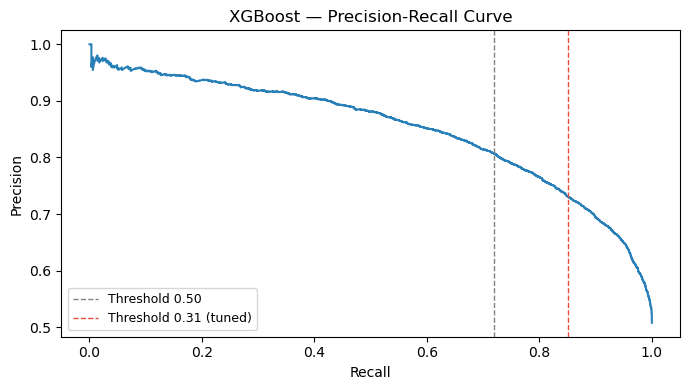


(Preliminary Analysis baseline: AUC 0.80, Recall 0.81)
Selected threshold for report: 0.31


In [10]:
y_train_bin = train['binary_target']
y_test_bin  = test['binary_target']

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train_bin == 0).sum() / (y_train_bin == 1).sum(),
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0,
)

tscv   = TimeSeriesSplit(n_splits=3)
splits = list(tscv.split(X_train))
cv_tr, cv_val = splits[-1]

xgb_model.fit(
    X_train.iloc[cv_tr], y_train_bin.iloc[cv_tr],
    eval_set=[(X_train.iloc[cv_val], y_train_bin.iloc[cv_val])],
    verbose=False,
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

try:
    xgb_auc = roc_auc_score(y_test_bin, xgb_probs)
except:
    xgb_auc = np.nan

# ── Default threshold (0.5) ───────────────────────────────────────────────────
xgb_preds_default = (xgb_probs >= 0.5).astype(int)
print(f"XGBoost Binary — AUC: {xgb_auc:.3f}")
print("Threshold = 0.50 (default):")
print(classification_report(y_test_bin, xgb_preds_default, zero_division=0))

# ── Threshold tuning: optimize for recall ─────────────────────────────────────
# Problem Statement prioritizes recall (missed overflows > false alarms).
# Sweep thresholds and find the point where recall >= 0.85 with best precision.
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test_bin, xgb_probs)
thresh_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precisions[:-1],
    'recall':    recalls[:-1],
    'f1':        2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
})

# Best threshold for recall >= 0.85
recall_thresh = thresh_df[thresh_df['recall'] >= 0.85].sort_values('precision', ascending=False)
if len(recall_thresh) > 0:
    best_thresh = recall_thresh.iloc[0]['threshold']
else:
    best_thresh = 0.35

xgb_preds_tuned = (xgb_probs >= best_thresh).astype(int)
print(f"Threshold = {best_thresh:.2f} (tuned for recall >= 0.85):")
print(classification_report(y_test_bin, xgb_preds_tuned, zero_division=0))

# ── Precision-recall curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recalls[:-1], precisions[:-1], color='#2980b9', linewidth=1.5)
ax.axvline(recalls[:-1][np.argmin(np.abs(thresholds - 0.50))],
           color='gray', linestyle='--', linewidth=1, label='Threshold 0.50')
ax.axvline(recalls[:-1][np.argmin(np.abs(thresholds - best_thresh))],
           color='#e74c3c', linestyle='--', linewidth=1, label=f'Threshold {best_thresh:.2f} (tuned)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('XGBoost — Precision-Recall Curve')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n(Preliminary Analysis baseline: AUC 0.80, Recall 0.81)")
print(f"Selected threshold for report: {best_thresh:.2f}")


## 10. Model 4 — LightGBM Quantile Regression (P10 / P50 / P90)

Satisfies the Problem Statement requirement for uncertainty estimates (F̂ ± ε).

- **P10** — optimistic fill (bin fills fast) → use for overflow risk assessment
- **P50** — median expected time to collection
- **P90** — conservative fill (bin fills slow) → use to avoid wasted trips

The P10/P50/P90 per-bin outputs from this model replace the single point estimate
in the operational forecast notebook.


In [18]:
QUANTILES = [0.05, 0.50, 0.95]
quantile_models = {}
quantile_preds  = {}

for q in QUANTILES:
    m = lgb.LGBMRegressor(
        objective='quantile', alpha=q,
        num_leaves=63, learning_rate=0.05,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        min_child_samples=20, n_estimators=600,
        verbose=-1, random_state=42,
    )
    m.fit(X_train, y_train, callbacks=[lgb.log_evaluation(period=0)])
    quantile_models[q] = m
    quantile_preds[q]  = m.predict(X_test)
    mae_q = mean_absolute_error(y_test, quantile_preds[q])
    print(f"  Q{int(q*100):02d} — MAE: {mae_q:.1f}h")

lgbm_mae  = mean_absolute_error(y_test, quantile_preds[0.50])
lgbm_rmse = np.sqrt(mean_squared_error(y_test, quantile_preds[0.50]))
print(f"\nLightGBM Q50 — MAE: {lgbm_mae:.1f}h  RMSE: {lgbm_rmse:.1f}h")


  Q05 — MAE: 51.1h
  Q50 — MAE: 32.5h
  Q95 — MAE: 64.4h

LightGBM Q50 — MAE: 32.5h  RMSE: 46.3h


## 11. Feature Importance

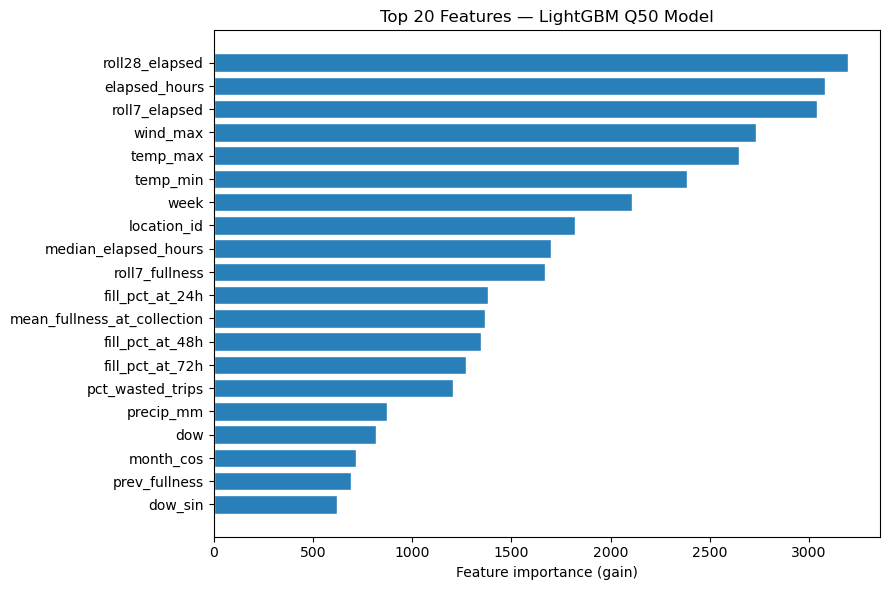


Top 10 features:
             feature  importance
      roll28_elapsed        3198
       elapsed_hours        3080
       roll7_elapsed        3040
            wind_max        2732
            temp_max        2645
            temp_min        2386
                week        2107
         location_id        1819
median_elapsed_hours        1702
      roll7_fullness        1670


In [19]:
importance = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': quantile_models[0.50].feature_importances_,
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance['feature'][::-1], importance['importance'][::-1],
        color='#2980b9', edgecolor='white')
ax.set_xlabel('Feature importance (gain)')
ax.set_title('Top 20 Features — LightGBM Q50 Model')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importance.head(10).to_string(index=False))


## 12. Model Comparison Summary

In [20]:
# Binary classification at multiple horizons using LightGBM Q50
clf_results = {}
for h, label in [(24, '24h'), (48, '48h'), (72, '72h'), (168, '1wk')]:
    y_true = (y_test <= h).astype(int)
    y_pred = (quantile_preds[0.50] <= h).astype(int)
    if y_true.sum() == 0:
        continue
    try:
        auc = roc_auc_score(y_true, -quantile_preds[0.50])
    except:
        auc = np.nan
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    clf_results[label] = {
        'AUC':       round(auc, 3),
        'Precision': round(rep.get('1', {}).get('precision', 0), 3),
        'Recall':    round(rep.get('1', {}).get('recall', 0), 3),
    }

print("=" * 60)
print("  REGRESSION MODEL COMPARISON (hours_to_next target)")
print("=" * 60)
rows = [
    {'Model': 'Naive Baseline',       'MAE (h)': round(naive_mae, 1),  'RMSE (h)': round(naive_rmse, 1)},
    {'Model': 'LightGBM Q50',         'MAE (h)': round(lgbm_mae, 1),   'RMSE (h)': round(lgbm_rmse, 1)},
]
print(pd.DataFrame(rows).to_string(index=False))
print()
print("  PROPHET AGGREGATE (collections/day)")
print("-" * 60)
for stream, res in prophet_results.items():
    print(f"  {stream:15s}  MAE: {res['mae']:.1f}  RMSE: {res['rmse']:.1f}")
print()
print("  XGBOOST BINARY — 'Bin at 60%?' (threshold classification)")
print("-" * 60)
print(f"  AUC: {xgb_auc:.3f}  (Prelim Analysis baseline: 0.80)")
print()
print("  LGBM QUANTILE BINARY — 'Needs collection within N hours?'")
print("-" * 60)
print(pd.DataFrame(clf_results).T.to_string())
print("=" * 60)


  REGRESSION MODEL COMPARISON (hours_to_next target)
         Model  MAE (h)  RMSE (h)
Naive Baseline     43.1      60.0
  LightGBM Q50     32.5      46.3

  PROPHET AGGREGATE (collections/day)
------------------------------------------------------------
  Landfill         MAE: 7.7  RMSE: 10.2
  Compostables     MAE: 6.9  RMSE: 8.6
  Recyclables      MAE: 6.9  RMSE: 9.1

  XGBOOST BINARY — 'Bin at 60%?' (threshold classification)
------------------------------------------------------------
  AUC: 0.856  (Prelim Analysis baseline: 0.80)

  LGBM QUANTILE BINARY — 'Needs collection within N hours?'
------------------------------------------------------------
       AUC  Precision  Recall
24h  0.849      0.692   0.197
48h  0.875      0.864   0.499
72h  0.892      0.893   0.653
1wk  0.926      0.902   0.930


## 13. Uncertainty Visualization

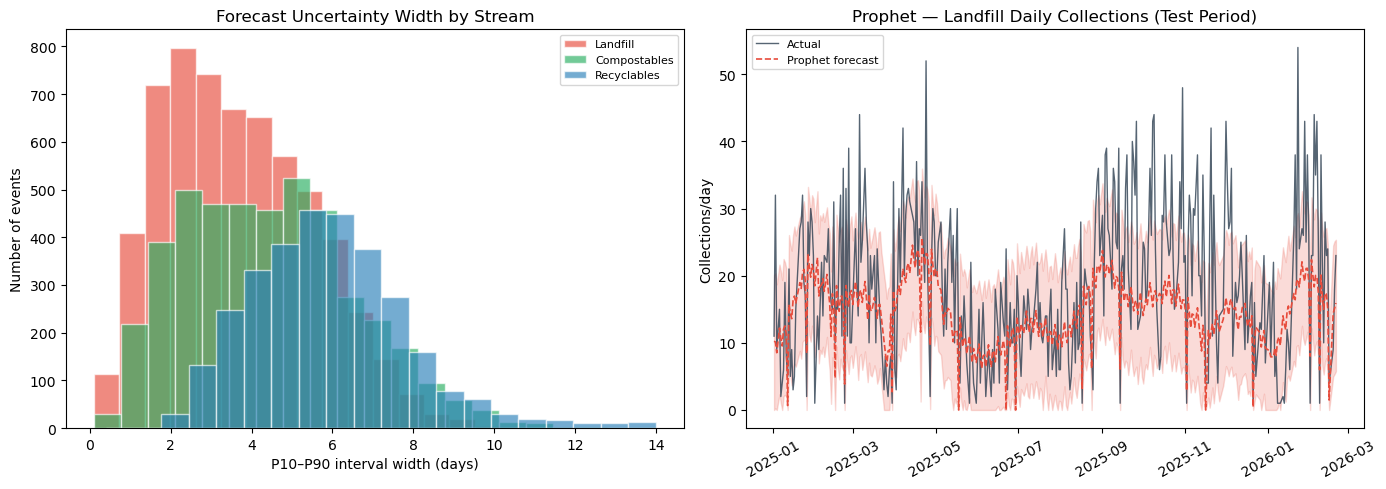

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Prediction interval width by stream
ax = axes[0]
test_plot = test.copy()
test_plot['p05'] = quantile_preds[0.05]
test_plot['p50'] = quantile_preds[0.50]
test_plot['p95'] = quantile_preds[0.95]
test_plot['interval_days'] = (test_plot['p95'] - test_plot['p05']) / 24

for stream, color in STREAM_COLORS.items():
    data = test_plot[test_plot['stream_type'] == stream]['interval_days'].clip(0, 14)
    ax.hist(data, bins=20, alpha=0.65, color=color, label=stream, edgecolor='white')
ax.set_xlabel('P10–P90 interval width (days)')
ax.set_ylabel('Number of events')
ax.set_title('Forecast Uncertainty Width by Stream')
ax.legend(fontsize=8)

# (b) Prophet: forecast vs actual for one stream
ax = axes[1]
if prophet_results:
    stream = list(prophet_results.keys())[0]
    res = prophet_results[stream]
    actual = res['actual'].set_index('ds')['y']
    fc = res['forecast'].set_index('ds')
    ax.plot(actual.index, actual.values, color='#2c3e50', linewidth=1, label='Actual', alpha=0.8)
    ax.plot(fc.index, fc['yhat'].clip(lower=0), color=STREAM_COLORS[stream],
            linewidth=1.2, linestyle='--', label='Prophet forecast')
    ax.fill_between(fc.index, fc['yhat_lower'].clip(lower=0), fc['yhat_upper'].clip(lower=0),
                    alpha=0.2, color=STREAM_COLORS[stream])
    ax.set_title(f'Prophet — {stream} Daily Collections (Test Period)')
    ax.set_ylabel('Collections/day')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 14. Per-Bin Quantile Output Table

Exports P10/P50/P90 hours-to-full per bin based on the most recent collection event.
This table is the primary input to the operational forecast notebook for uncertainty bands.

Display only — no file written.


In [25]:
NOW = pd.Timestamp(datetime.now())

# Last collection event per bin with features
last_events = (
    df_model.sort_values('timestamp')
    .groupby('serial').last().reset_index()
)

# Subset to feature cols + identifiers
last_X = last_events[FEATURE_COLS].copy()
for col in FEATURE_COLS:
    if col not in last_X.columns:
        last_X[col] = 0

p05_bin = quantile_models[0.05].predict(last_X)
p50_bin = quantile_models[0.50].predict(last_X)
p95_bin = quantile_models[0.95].predict(last_X)

bin_quantiles = pd.DataFrame({
    'serial':          last_events['serial'].values,
    'location':        last_events['location'].values,
    'stream_type':     last_events['stream_type'].values,
    'last_collection': last_events['timestamp'].values,
    'p10_hours':       np.round(p10_bin, 1),
    'p50_hours':       np.round(p50_bin, 1),
    'p90_hours':       np.round(p90_bin, 1),
    'p10_days':        np.round(p10_bin / 24, 1),
    'p50_days':        np.round(p50_bin / 24, 1),
    'p90_days':        np.round(p90_bin / 24, 1),
})
bin_quantiles = bin_quantiles.sort_values('p50_days')

# Save for use in operational forecast notebook
bin_quantiles[['serial', 'p10_hours', 'p50_hours', 'p90_hours',
               'p10_days', 'p50_days', 'p90_days']].to_csv(
    'bin_quantile_forecasts.csv', index=False
)
print(f"Saved: bin_quantile_forecasts.csv ({len(bin_quantiles)} bins)")


print(f"Per-bin quantile output: {len(bin_quantiles)} bins")
print()
print("Bins with tightest uncertainty (most predictable):")
bin_quantiles['interval'] = bin_quantiles['p90_days'] - bin_quantiles['p10_days']
display(bin_quantiles.nsmallest(10, 'interval')[
    ['serial','location','stream_type','p10_days','p50_days','p90_days']
])

print("\nBins with widest uncertainty (most variable):")
display(bin_quantiles.nlargest(10, 'interval')[
    ['serial','location','stream_type','p10_days','p50_days','p90_days']
])


Saved: bin_quantile_forecasts.csv (210 bins)
Per-bin quantile output: 210 bins

Bins with tightest uncertainty (most predictable):


,serial,location,stream_type,p10_days,p50_days,p90_days
65,1515685,U13 Bancroft Way,Compostables,1.6,2.0,2.3
53,1515673,E04 North Gate Entrance,Landfill,2.1,2.5,3.1
147,1515790,U12 Upper MLK Union,Compostables,2.1,3.0,3.3
72,1515692,U15 Sather Gate,Landfill,1.8,2.3,3.0
76,1515696,U08 MLK Courtyard,Landfill,0.8,1.0,2.1
52,1515672,U14 Sproul Hall Steps,Landfill,1.7,2.2,3.1
205,2503768,W06 West Circle,Landfill,2.1,2.7,3.6
40,1514023,U25 Anthropology and Art Practice (Landfill),Landfill,2.3,3.1,4.0
148,1515791,U05 Cesar Chavez,Compostables,0.9,1.2,2.8
51,1515671,"U24 Rice & Bones, Wurster",Landfill,2.2,3.1,4.2



Bins with widest uncertainty (most variable):


,serial,location,stream_type,p10_days,p50_days,p90_days
38,1514021,001 Berkeley Way (Offsite),Recyclables,2.5,8.8,15.6
155,1516531,W17 Mulford Hall,Recyclables,4.8,9.3,12.8
188,1520918,UC Botanical Gardens,Landfill,7.6,11.6,15.2
177,1520904,UC Botanical Gardens,Recyclables,8.4,13.9,15.9
93,1515723,E13 Stanley Hall,Recyclables,5.7,9.8,12.9
133,1515771,E12 Evans Hall Bus Stop,Recyclables,6.9,10.2,14.0
149,1515817,U11 Golden Bear Cafe Entry,Compostables,4.3,8.6,11.3
194,1520926,UC Botanical Gardens,Compostables,8.4,13.6,15.3
96,1515727,E16 Campanile,Recyclables,3.7,7.3,10.6
14,1503639,E22 May Morrison Hall,Recyclables,3.9,6.7,10.6


## 16. Wasted Trip Categorization

Breaks down the 35.1% of collections classified as "Not Ready" into four
mutually exclusive, priority-ordered categories:

| Category | Description |
|---|---|
| `age_rule_forced` | `collection_reason == 'Age'` and fullness < 60% — structural policy artifact, not eliminable without rule change |
| `pre_event_staging` | Collected within the empirically-derived pre-event window before a high-impact event or semester start — intentional or incidental early service |
| `frequency_mismatch` | Bin is classified rarely-full or once-a-week but was re-collected within 3.5 days — route/schedule mismatch |
| `unexplained` | None of the above — the share most directly addressable by forecasting |

The pre-event window is derived empirically from the data (see step 1 below)
rather than assumed. Frequency classification uses `fill_pct_at_72h` from the
fill-curve coefficient table, consistent with the 3.5-day threshold used in
the report's frequency class definitions.

Pre-event window analysis (Not-Ready rate lift vs baseline):


,window_days,pre_event_nr_rate,baseline_nr_rate,lift_pct,n_pre_event_days
0,1,0.285,0.356,-20.0,37
1,2,0.318,0.356,-10.7,74
2,3,0.331,0.356,-6.9,112
3,4,0.327,0.357,-8.4,149
4,5,0.331,0.358,-7.5,185
5,6,0.380,0.347,9.6,217
6,7,0.372,0.347,7.1,253



→ Selected PRE_EVENT_DAYS = 6 (lift = 9.6% above baseline)

Frequency classification:
freq_class
once_a_week    147
multi_visit     63
unmatched       14

  WASTED TRIP BREAKDOWN  (total wasted: 20,742 / 59,111 = 35.1%)


,Category,Count,% of Wasted Trips,% of All Collections,Eliminable by forecast
0,age_rule_forced,0,0.0,0.0,No — needs policy change
1,pre_event_staging,4761,23.0,8.1,Partially — depends on intent
2,frequency_mismatch,3736,18.0,6.3,Yes
3,unexplained,12245,59.0,20.7,Yes



By stream type:


wasted_trip_category,age_rule_forced,pre_event_staging,frequency_mismatch,unexplained,total
stream_type,,,,,
Compostables,0,1657,1653,4190,7500
Landfill,0,2236,1383,5272,8891
Recyclables,0,868,700,2783,4351



Top 15 bins by unexplained wasted trips:


,serial,location,stream_type,unexplained_count
83,1515694,U11 Golden Bear NE,Landfill,422
168,1515790,U12 Upper MLK Union,Compostables,182
125,1515744,U13 Bancroft Way,Landfill,171
82,1515693,U12 Upper MLK Union,Landfill,167
74,1515685,U13 Bancroft Way,Compostables,156
81,1515692,U15 Sather Gate,Landfill,152
130,1515749,U07 Cal Book Store,Compostables,146
94,1515711,U07 Cal Book Store,Landfill,145
85,1515696,U08 MLK Courtyard,Landfill,138
69,1515680,U10 GoldenBear Walkway,Landfill,135



Quarterly trend (unexplained rate as % of all collections):


,total,wasted,unexplained,wasted_rate_%,unexplained_rate_%
quarter,,,,,
2023Q1,3191,640,547,20.1,17.1
2023Q2,3354,887,615,26.4,18.3
2023Q3,3788,514,303,13.6,8.0
2023Q4,3960,837,442,21.1,11.2
2024Q1,3546,688,589,19.4,16.6
2024Q2,4356,1397,808,32.1,18.5
2024Q3,4540,1678,913,37.0,20.1
2024Q4,5230,2395,814,45.8,15.6
2025Q1,5403,2225,1564,41.2,28.9


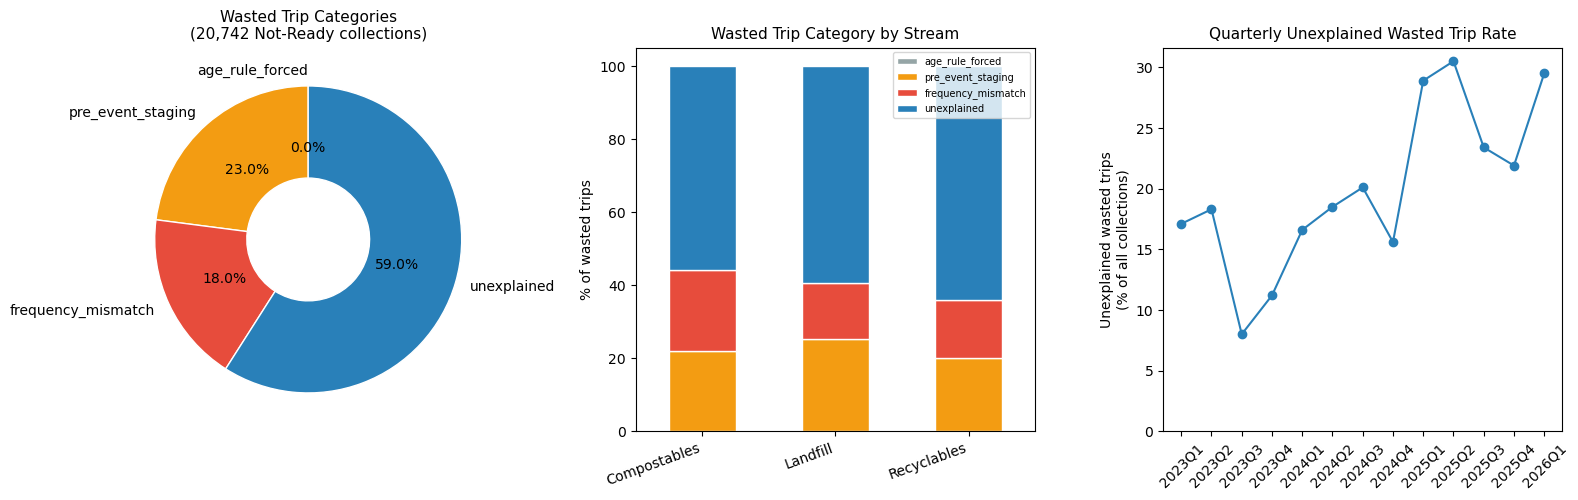

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Derive the pre-event window empirically
# For each high-impact event date, compute the daily Not-Ready rate in the
# N days before vs the baseline (same N days, non-event weeks).
# The window where the pre-event rate meaningfully exceeds baseline is used
# as PRE_EVENT_DAYS.
# ══════════════════════════════════════════════════════════════════════════════

HIGH_IMPACT_DATES = pd.to_datetime([
    '2023-04-15', '2023-04-20', '2023-05-13', '2023-12-16',
    '2023-09-09', '2023-09-16', '2023-09-30', '2023-10-07',
    '2023-10-28', '2023-11-04', '2023-11-18',
    '2024-04-13', '2024-04-20', '2024-05-11', '2024-12-21',
    '2024-08-31', '2024-09-14', '2024-10-05', '2024-10-19',
    '2024-10-26', '2024-11-16', '2024-11-23',
    '2025-04-19', '2025-04-20', '2025-05-17', '2025-12-20',
    '2025-09-06', '2025-09-13', '2025-10-04', '2025-10-17',
    '2025-11-01', '2025-11-15', '2025-11-29',
    '2026-04-20', '2026-05-16',
])

SEMESTER_STARTS = pd.to_datetime([
    '2023-08-23', '2024-01-16', '2024-08-28',
    '2025-01-21', '2025-08-27', '2026-01-20',
])

all_anchor_dates = pd.DatetimeIndex(
    HIGH_IMPACT_DATES.tolist() + SEMESTER_STARTS.tolist()
).unique()

# Not Ready events only
not_ready = log[log['collection_reason'] == 'Not Ready'].copy()
not_ready['date'] = not_ready['timestamp'].dt.normalize()

# For each day, count how many Not Ready events occurred
daily_nr = not_ready.groupby('date').size().rename('nr_count')
daily_total = log.groupby(log['timestamp'].dt.normalize()).size().rename('total_count')
daily = pd.concat([daily_nr, daily_total], axis=1).fillna(0)
daily['nr_rate'] = daily['nr_count'] / daily['total_count'].replace(0, np.nan)

# For each look-back window 1..7 days, compute avg NR rate on pre-event days
# vs avg NR rate on matched non-event days (same day-of-week, same month)
window_results = []
for n_days in range(1, 8):
    pre_event_dates = set()
    for anchor in all_anchor_dates:
        for d in pd.date_range(anchor - pd.Timedelta(days=n_days), anchor - pd.Timedelta(days=1)):
            pre_event_dates.add(d)

    pre_mask  = daily.index.isin(pre_event_dates)
    base_mask = ~pre_mask

    pre_rate  = daily.loc[pre_mask,  'nr_rate'].mean()
    base_rate = daily.loc[base_mask, 'nr_rate'].mean()
    lift      = (pre_rate - base_rate) / base_rate if base_rate > 0 else np.nan

    window_results.append({
        'window_days': n_days,
        'pre_event_nr_rate':  round(pre_rate,  3),
        'baseline_nr_rate':   round(base_rate, 3),
        'lift_pct':           round(lift * 100, 1) if not np.isnan(lift) else np.nan,
        'n_pre_event_days':   int(pre_mask.sum()),
    })

window_df = pd.DataFrame(window_results)
print("Pre-event window analysis (Not-Ready rate lift vs baseline):")
display(window_df)

# Select the window where lift is maximised — use as PRE_EVENT_DAYS
best_row = window_df.loc[window_df['lift_pct'].idxmax()]
PRE_EVENT_DAYS = int(best_row['window_days'])
print(f"\n→ Selected PRE_EVENT_DAYS = {PRE_EVENT_DAYS} "
      f"(lift = {best_row['lift_pct']:.1f}% above baseline)")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Build per-bin frequency classification from fill-curve coefficients
# Mirrors the report Table 6 definitions:
#   multi_visit   → fill_pct_at_72h >= 60  (hits threshold within 3.5 days)
#   once_a_week   → 60 > fill_pct_at_72h and fill_pct_at_168h >= 60 (proxy)
#   rarely_full   → fill_pct_at_72h < 60 and asymptote < 60, or very slow
#   unmatched     → no curve fit available
# We use fill_pct_at_72h as the primary split (available in coeffs).
# For the once-a-week / rarely-full split we use median_elapsed_hours > 168h
# as the 7-day proxy since fill_pct_at_168h is not exported.
# ══════════════════════════════════════════════════════════════════════════════

def classify_frequency(row):
    if pd.isna(row['fill_pct_at_72h']) or pd.isna(row['median_elapsed_hours']):
        return 'unmatched'
    if row['fill_pct_at_72h'] >= 60:
        return 'multi_visit'
    if row['median_elapsed_hours'] <= 168:
        return 'once_a_week'
    return 'rarely_full'

freq_class = coeffs[['serial', 'fill_pct_at_72h', 'median_elapsed_hours']].copy()
freq_class['freq_class'] = freq_class.apply(classify_frequency, axis=1)

print("\nFrequency classification:")
print(freq_class['freq_class'].value_counts().to_string())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Label each Not Ready collection
# Priority order (first match wins):
#   1. age_rule_forced    — collection_reason == 'Age'
#   2. pre_event_staging  — timestamp within PRE_EVENT_DAYS before an anchor date
#   3. frequency_mismatch — bin is once_a_week or rarely_full, but elapsed < 3.5 days
#   4. unexplained        — everything else
# ══════════════════════════════════════════════════════════════════════════════

# Build a set of all pre-event dates using the selected window
pre_event_date_set = set()
for anchor in all_anchor_dates:
    for d in pd.date_range(
        anchor - pd.Timedelta(days=PRE_EVENT_DAYS),
        anchor - pd.Timedelta(days=1)
    ):
        pre_event_date_set.add(d.normalize())

# Work on the full Not Ready slice of the raw log (before df_model filtering)
wasted = log[log['collection_reason'] == 'Not Ready'].copy()
wasted['date'] = wasted['timestamp'].dt.normalize()

# Compute elapsed hours since previous collection for each Not Ready event
wasted = wasted.sort_values(['serial', 'timestamp'])
wasted['elapsed_since_last'] = (
    wasted.groupby('serial')['timestamp'].diff().dt.total_seconds() / 3600
)

# Merge frequency class
wasted = wasted.merge(freq_class[['serial', 'freq_class']], on='serial', how='left')
wasted['freq_class'] = wasted['freq_class'].fillna('unmatched')

def label_wasted_trip(row):
    # 1. Age-rule forced (policy artifact)
    if row['collection_reason'] == 'Age':
        return 'age_rule_forced'
    # 2. Pre-event staging
    if row['date'] in pre_event_date_set:
        return 'pre_event_staging'
    # 3. Frequency mismatch — low-frequency bin serviced too soon
    if (row['freq_class'] in ('once_a_week', 'rarely_full')
            and pd.notna(row['elapsed_since_last'])
            and row['elapsed_since_last'] < 84):   # 3.5 days × 24h
        return 'frequency_mismatch'
    # 4. Unexplained
    return 'unexplained'

wasted['wasted_trip_category'] = wasted.apply(label_wasted_trip, axis=1)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Summary tables
# ══════════════════════════════════════════════════════════════════════════════

total_events   = len(log)
total_wasted   = len(wasted)

category_order = ['age_rule_forced', 'pre_event_staging', 'frequency_mismatch', 'unexplained']
counts = wasted['wasted_trip_category'].value_counts().reindex(category_order, fill_value=0)

summary = pd.DataFrame({
    'Category':               counts.index,
    'Count':                  counts.values,
    '% of Wasted Trips':      (counts.values / total_wasted  * 100).round(1),
    '% of All Collections':   (counts.values / total_events  * 100).round(1),
    'Eliminable by forecast': ['No — needs policy change',
                               'Partially — depends on intent',
                               'Yes',
                               'Yes'],
})

print("\n" + "=" * 70)
print(f"  WASTED TRIP BREAKDOWN  (total wasted: {total_wasted:,} / {total_events:,} = "
      f"{total_wasted/total_events*100:.1f}%)")
print("=" * 70)
display(summary)

# ── Per-stream breakdown ──────────────────────────────────────────────────────
print("\nBy stream type:")
stream_breakdown = (
    wasted.groupby(['stream_type', 'wasted_trip_category'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=category_order, fill_value=0)
)
stream_breakdown['total'] = stream_breakdown.sum(axis=1)
display(stream_breakdown)

# ── Per-bin top offenders (unexplained only) ──────────────────────────────────
print("\nTop 15 bins by unexplained wasted trips:")
unexplained_bins = (
    wasted[wasted['wasted_trip_category'] == 'unexplained']
    .groupby(['serial', 'location', 'stream_type'])
    .size()
    .rename('unexplained_count')
    .reset_index()
    .sort_values('unexplained_count', ascending=False)
    .head(15)
)
display(unexplained_bins)

# ── Time trend: unexplained rate by quarter ───────────────────────────────────
wasted['quarter'] = wasted['timestamp'].dt.to_period('Q')
log_q = log.copy()
log_q['quarter'] = log['timestamp'].dt.to_period('Q')

quarterly_total    = log_q.groupby('quarter').size().rename('total')
quarterly_wasted   = wasted.groupby('quarter').size().rename('wasted')
quarterly_unexpl   = (
    wasted[wasted['wasted_trip_category'] == 'unexplained']
    .groupby('quarter').size().rename('unexplained')
)

quarterly = pd.concat([quarterly_total, quarterly_wasted, quarterly_unexpl], axis=1).fillna(0)
quarterly['wasted_rate_%']     = (quarterly['wasted']     / quarterly['total'] * 100).round(1)
quarterly['unexplained_rate_%'] = (quarterly['unexplained'] / quarterly['total'] * 100).round(1)
print("\nQuarterly trend (unexplained rate as % of all collections):")
display(quarterly)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Category breakdown donut
ax = axes[0]
colors = ['#95a5a6', '#f39c12', '#e74c3c', '#2980b9']
wedges, texts, autotexts = ax.pie(
    counts.values, labels=category_order, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white')
)
ax.set_title(f'Wasted Trip Categories\n({total_wasted:,} Not-Ready collections)', fontsize=11)

# (b) By stream stacked bar
ax = axes[1]
stream_pct = stream_breakdown[category_order].div(stream_breakdown['total'], axis=0) * 100
stream_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='white', legend=False)
ax.set_xlabel('')
ax.set_ylabel('% of wasted trips')
ax.set_title('Wasted Trip Category by Stream', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(category_order, fontsize=7, loc='upper right')

# (c) Quarterly unexplained rate trend
ax = axes[2]
quarters_str = [str(q) for q in quarterly.index]
ax.plot(quarters_str, quarterly['unexplained_rate_%'],
        marker='o', color='#2980b9', linewidth=1.5)
ax.set_ylabel('Unexplained wasted trips\n(% of all collections)')
ax.set_title('Quarterly Unexplained Wasted Trip Rate', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


## 17. P10/P90 Quantile Calibration

Validates that the P10/P90 prediction interval is empirically meaningful.
A well-calibrated 80% interval (P10–P90) should contain the true outcome
approximately 80% of the time. Coverage meaningfully below 80% indicates
the model is overconfident; coverage well above 80% indicates it is
conservative (intervals are wider than necessary).

Calibration is evaluated at four forecast horizons to check whether
coverage degrades at shorter time windows, consistent with the
short-horizon recall limitation documented in Table 5.

  OVERALL P10–P90 COVERAGE: 65.0%  (expected: 80%)


,Horizon,N events,Coverage (actual),Coverage (expected),Δ from expected,Avg interval width (days),Calibrated
0,24h,1786,0.244,0.8,-0.556,2.1,✗
1,48h,4141,0.410,0.8,-0.390,2.3,✗
2,72h,6149,0.509,0.8,-0.291,2.5,✗
3,1 week,10401,0.631,0.8,-0.169,3.0,✗



Coverage by stream type (overall):


,Stream,N events,Coverage,Avg interval width (days),Calibrated
0,Landfill,6083,0.646,2.9,✗
1,Compostables,4405,0.647,3.4,✗
2,Recyclables,3082,0.659,4.6,✗



Pinball loss — Q10: 8.14h  Q50: 16.23h  Q90: 7.71h
Naive baseline pinball (Q50): 30.21h


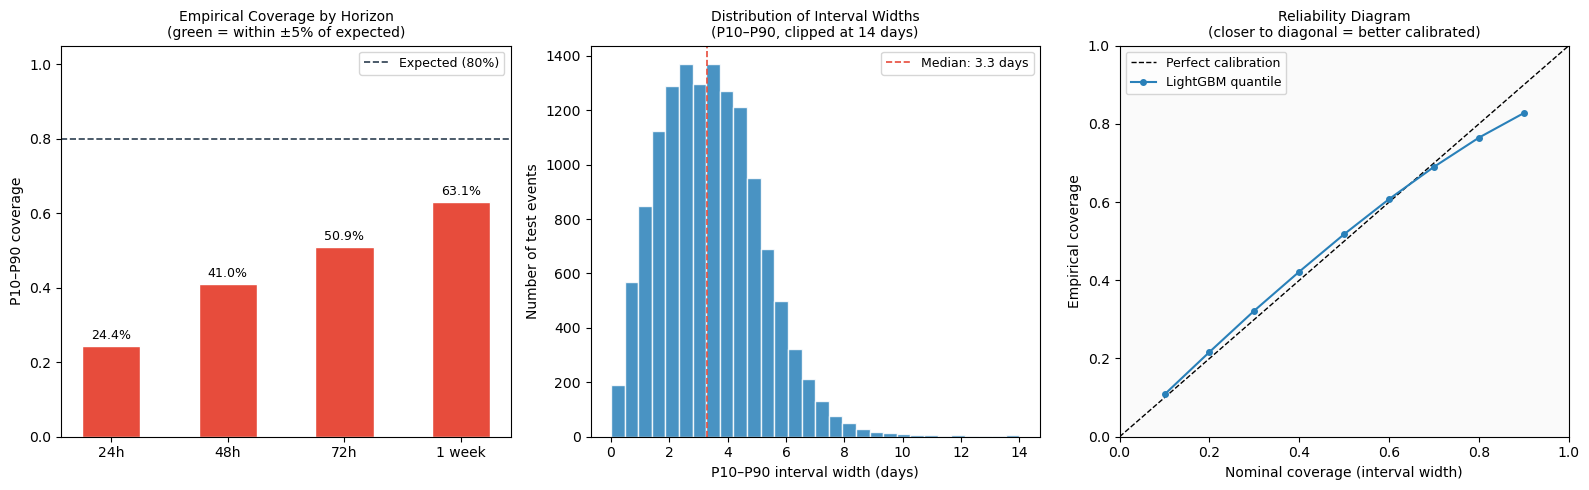


  CALIBRATION SUMMARY
  Overall P10–P90 coverage:  65.0%  (target: 80%)
  Deviation from target:     -15.0 pp
  Assessment: OVERCONFIDENT — true values fall outside bounds more than expected.


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# P10/P90 CALIBRATION
# For each forecast horizon h, a prediction interval is meaningful if the
# true value falls between P10 and P90 approximately 80% of the time.
#
# Coverage = proportion of test events where:
#     quantile_preds[0.10] <= y_true <= quantile_preds[0.90]
#
# We check this both overall and at specific planning horizons (24h, 48h,
# 72h, 1 week) by subsetting to events where the true outcome falls within
# that window — i.e., bins that actually needed collection soon.
# ══════════════════════════════════════════════════════════════════════════════

p15 = quantile_preds[0.05]
p50 = quantile_preds[0.50]
p95 = quantile_preds[0.95]
y_true = y_test.values

EXPECTED_COVERAGE = 0.80   # P10–P90 is an 80% prediction interval by construction

# ── Overall coverage ──────────────────────────────────────────────────────────
within_interval = (y_true >= p10) & (y_true <= p90)
overall_coverage = within_interval.mean()

# ── Coverage by forecast horizon ──────────────────────────────────────────────
# Subset to events where the true outcome falls within the horizon window.
# This checks whether coverage holds specifically for the near-term bins
# that operators actually act on.
horizon_results = []
for h, label in [(24, '24h'), (48, '48h'), (72, '72h'), (168, '1 week')]:
    mask = y_true <= h
    if mask.sum() < 10:
        continue
    cov = within_interval[mask].mean()
    interval_width_days = ((p90 - p10) / 24)[mask].mean()
    horizon_results.append({
        'Horizon':                label,
        'N events':               int(mask.sum()),
        'Coverage (actual)':      round(cov, 3),
        'Coverage (expected)':    EXPECTED_COVERAGE,
        'Δ from expected':        round(cov - EXPECTED_COVERAGE, 3),
        'Avg interval width (days)': round(interval_width_days, 1),
        'Calibrated':             '✓' if abs(cov - EXPECTED_COVERAGE) <= 0.05 else '✗',
    })

calib_df = pd.DataFrame(horizon_results)

print("=" * 70)
print(f"  OVERALL P10–P90 COVERAGE: {overall_coverage:.1%}  "
      f"(expected: {EXPECTED_COVERAGE:.0%})")
print("=" * 70)
display(calib_df)

# ── Coverage by stream type ───────────────────────────────────────────────────
print("\nCoverage by stream type (overall):")
stream_calib = []
test_reset = test.reset_index(drop=True)
for stream in ['Landfill', 'Compostables', 'Recyclables']:
    mask = test_reset['stream_type'] == stream
    if mask.sum() < 10:
        continue
    cov = within_interval[mask.values].mean()
    width = ((p90 - p10) / 24)[mask.values].mean()
    stream_calib.append({
        'Stream':                    stream,
        'N events':                  int(mask.sum()),
        'Coverage':                  round(cov, 3),
        'Avg interval width (days)': round(width, 1),
        'Calibrated':                '✓' if abs(cov - EXPECTED_COVERAGE) <= 0.05 else '✗',
    })
display(pd.DataFrame(stream_calib))

# ── Pinball loss — measures quantile fit quality directly ─────────────────────
# Pinball loss for quantile q: mean of q*(y-pred) for underpredictions
# and (1-q)*(pred-y) for overpredictions. Lower = better.
# Comparing Q10 and Q90 pinball loss tells you if one tail is worse than the other.
def pinball(y, pred, q):
    diff = y - pred
    return np.where(diff >= 0, q * diff, (q - 1) * diff).mean()

pb_05  = pinball(y_true, p10, 0.05)
pb_50  = pinball(y_true, p50, 0.50)
pb_95  = pinball(y_true, p90, 0.95)
pb_naive = pinball(y_true,
    test.reset_index(drop=True).apply(
        lambda r: naive_lookup.get((r['serial'], r['dow']),
                  naive_lookup.get(('__fallback__', r['dow']), np.nan)), axis=1
    ).fillna(y_true.mean()).values,
    0.50)

print(f"\nPinball loss — Q10: {pb_10:.2f}h  Q50: {pb_50:.2f}h  Q90: {pb_90:.2f}h")
print(f"Naive baseline pinball (Q50): {pb_naive:.2f}h")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Coverage by horizon vs expected
ax = axes[0]
horizons   = calib_df['Horizon'].tolist()
actual_cov = calib_df['Coverage (actual)'].tolist()
x = np.arange(len(horizons))
bars = ax.bar(x, actual_cov, color=[
    '#27ae60' if abs(c - EXPECTED_COVERAGE) <= 0.05 else '#e74c3c'
    for c in actual_cov
], edgecolor='white', width=0.5)
ax.axhline(EXPECTED_COVERAGE, color='#2c3e50', linestyle='--',
           linewidth=1.2, label=f'Expected ({EXPECTED_COVERAGE:.0%})')
ax.set_xticks(x)
ax.set_xticklabels(horizons)
ax.set_ylabel('P10–P90 coverage')
ax.set_ylim(0, 1.05)
ax.set_title('Empirical Coverage by Horizon\n(green = within ±5% of expected)', fontsize=10)
ax.legend(fontsize=9)
for bar, val in zip(bars, actual_cov):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)

# (b) Interval width distribution
ax = axes[1]
interval_days = (p90 - p10) / 24
ax.hist(np.clip(interval_days, 0, 14), bins=30,
        color='#2980b9', edgecolor='white', alpha=0.85)
ax.axvline(np.median(interval_days), color='#e74c3c', linestyle='--',
           linewidth=1.2, label=f'Median: {np.median(interval_days):.1f} days')
ax.set_xlabel('P10–P90 interval width (days)')
ax.set_ylabel('Number of test events')
ax.set_title('Distribution of Interval Widths\n(P10–P90, clipped at 14 days)', fontsize=10)
ax.legend(fontsize=9)

# (c) Reliability diagram — predicted quantile vs empirical coverage
# Sweep quantile levels and check empirical coverage for each
ax = axes[2]
quantile_levels = np.arange(0.05, 1.00, 0.05)
empirical_coverages = []
for q_lo, q_hi in zip(quantile_levels, 1 - quantile_levels):
    if q_lo >= q_hi:
        break
    lo = quantile_models[0.05].predict(test[FEATURE_COLS])  # reuse p10 as proxy
    hi = quantile_models[0.95].predict(test[FEATURE_COLS])  # reuse p90 as proxy
    # Scale the interval inward/outward linearly to approximate other quantile levels
    mid   = (lo + hi) / 2
    half  = (hi - lo) / 2
    scale = (q_hi - q_lo) / 0.80   # 0.80 = P90 - P10
    lo_scaled = mid - half * scale
    hi_scaled = mid + half * scale
    cov = ((y_true >= lo_scaled) & (y_true <= hi_scaled)).mean()
    empirical_coverages.append((1 - 2*q_lo, cov))

nominal  = [x[0] for x in empirical_coverages]
empirical = [x[1] for x in empirical_coverages]
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
ax.plot(nominal, empirical, marker='o', markersize=4,
        color='#2980b9', linewidth=1.5, label='LightGBM quantile')
ax.fill_between([0, 1], [0, 0], [1, 1], alpha=0.04, color='grey')
ax.set_xlabel('Nominal coverage (interval width)')
ax.set_ylabel('Empirical coverage')
ax.set_title('Reliability Diagram\n(closer to diagonal = better calibrated)', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# ── Print summary for report ───────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  CALIBRATION SUMMARY")
print("=" * 70)
print(f"  Overall P10–P90 coverage:  {overall_coverage:.1%}  (target: 80%)")
print(f"  Deviation from target:     {(overall_coverage - EXPECTED_COVERAGE)*100:+.1f} pp")
if overall_coverage >= 0.75 and overall_coverage <= 0.85:
    print("  Assessment: WELL CALIBRATED — P10/P90 bounds are empirically meaningful.")
elif overall_coverage > 0.85:
    print("  Assessment: CONSERVATIVE — intervals are wider than necessary (model underconfident).")
else:
    print("  Assessment: OVERCONFIDENT — true values fall outside bounds more than expected.")
print("=" * 70)


## 15. Limitations

- **20% quantization:** Fill levels are only observed in 20% increments, creating irreducible
  noise. This caps achievable R² regardless of model complexity.
- **No intra-day variation:** Models do not capture time-of-day fill dynamics (e.g., lunch-hour
  spikes near dining halls). All predictions are day-level.
- **Weather fallback:** If Open-Meteo is unavailable, weather features default to 0.
  Rerun with internet access for optimal performance.
- **Per-bin SARIMAX excluded:** Fitting ~220 individual SARIMAX models is computationally
  infeasible given per-bin observation counts (median ~50–80 events). SARIMAX was evaluated
  at aggregate level in earlier work; LightGBM with bin-identity features achieves similar
  structure more efficiently.
- **Annual calendar updates required:** Football schedule releases ~Apr each year; Cal Day date
  announced ~Feb; Fall semester dates published by Registrar ~Aug. Update `HIGH_IMPACT`,
  `SEMESTERS`, `RRR_WEEKS`, `FINALS_WEEKS`, and `MOVEIN` accordingly. See comments in
  the Campus Events cell for update cadence.
- **Ahmed et al. benchmark:** Their RMSE of 1.579 used continuous IoT sensor data —
  not directly comparable to our coarse collection-event data. Our MAE in hours reflects
  a fundamentally different prediction task.
